## baseline + LSTM

In [1]:
import shap
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['LGBM_VERBOSITY'] = '-1'

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df_match = pd.read_parquet('df_match.parquet')

## 根据选手的历史特征，去预测新的比赛结果

In [2]:
df_match.head()

,uid,Player,ELO,Target,Date,Δi_Hist,D_Hist,Is_Optimal_Hist,Is_Error_Hist,Is_Blunder_Hist,...,D_Hist_Diff,Is_Optimal_Hist_Diff,Is_Error_Hist_Diff,Is_Blunder_Hist_Diff,Cog_Speed_S1_Hist_Diff,Cog_Speed_S2_Hist_Diff,Cog_Speed_S3_Hist_Diff,TM_S1_Hist_Diff,TM_S2_Hist_Diff,TM_S3_Hist_Diff
0,906130,Alberto Barp,2590.0,-1.0,2020-03-04,0.515489,0.452265,0.596109,0.042447,0.025628,...,-0.047227,0.048248,-0.006961,0.008536,0.210064,-0.139083,-0.060317,0.009,0.098,0.237
1,906130,Krikor Sevag Mekhitarian,2826.0,1.0,2020-03-04,21.448369,0.499492,0.547861,0.049408,0.017091,...,0.047227,-0.048248,0.006961,-0.008536,-0.210064,0.139083,0.060317,-0.009,-0.098,-0.237
2,906151,Maksim Chigaev,2901.0,1.0,2020-03-04,43.069367,0.463297,0.625794,0.039385,0.016282,...,-0.039368,0.047202,-0.013699,-0.006000,-0.643110,-0.231066,-0.764103,0.014,0.001,-0.258
3,906151,Ronald Brizuela,2624.0,-1.0,2020-03-04,93.113105,0.502665,0.578591,0.053084,0.022282,...,0.039368,-0.047202,0.013699,0.006000,0.643110,0.231066,0.764103,-0.014,-0.001,0.258
4,906176,Chelsie Monica Ignesias Sihite,2160.0,1.0,2020-03-04,125.572323,0.493892,0.416379,0.094040,0.057624,...,-0.041179,-0.182185,0.024030,0.017090,0.440413,-0.241951,-0.316492,-0.015,-0.201,-0.290


In [3]:
df_match.columns

Index(['uid', 'Player', 'ELO', 'Target', 'Date', 'Δi_Hist', 'D_Hist',
       'Is_Optimal_Hist', 'Is_Error_Hist', 'Is_Blunder_Hist',
       'Cog_Speed_S1_Hist', 'Cog_Speed_S2_Hist', 'Cog_Speed_S3_Hist',
       'TM_S1_Hist', 'TM_S2_Hist', 'TM_S3_Hist', 'Player_Opp', 'ELO_Opp',
       'Target_Opp', 'Δi_Hist_Opp', 'D_Hist_Opp', 'Is_Optimal_Hist_Opp',
       'Is_Error_Hist_Opp', 'Is_Blunder_Hist_Opp', 'Cog_Speed_S1_Hist_Opp',
       'Cog_Speed_S2_Hist_Opp', 'Cog_Speed_S3_Hist_Opp', 'TM_S1_Hist_Opp',
       'TM_S2_Hist_Opp', 'TM_S3_Hist_Opp', 'ELO_Diff', 'Δi_Hist_Diff',
       'D_Hist_Diff', 'Is_Optimal_Hist_Diff', 'Is_Error_Hist_Diff',
       'Is_Blunder_Hist_Diff', 'Cog_Speed_S1_Hist_Diff',
       'Cog_Speed_S2_Hist_Diff', 'Cog_Speed_S3_Hist_Diff', 'TM_S1_Hist_Diff',
       'TM_S2_Hist_Diff', 'TM_S3_Hist_Diff'],
      dtype='object')

In [4]:
df_match = df_match.copy()
df_match = df_match[df_match['Target'] != 0.0].reset_index(drop=True)
df_match = df_match.sort_values('Date')
df_match = df_match.groupby('uid').first().reset_index()

drop_cols = ['uid', 'Player', 'Player_Opp', 'Date', 'Target', 'Target_Opp',
             'ELO', 'ELO_Diff', 'ELO_Opp',
             'Δi_Hist','D_Hist','Is_Optimal_Hist','Is_Error_Hist','Is_Blunder_Hist',
             'Cog_Speed_S1_Hist','Cog_Speed_S2_Hist','Cog_Speed_S3_Hist',
             'TM_S1_Hist','TM_S2_Hist','TM_S3_Hist',
             'Δi_Hist_Opp','D_Hist_Opp','Is_Optimal_Hist_Opp','Is_Error_Hist_Opp','Is_Blunder_Hist_Opp',
             'Cog_Speed_S1_Hist_Opp','Cog_Speed_S2_Hist_Opp','Cog_Speed_S3_Hist_Opp',
             'TM_S1_Hist_Opp','TM_S2_Hist_Opp','TM_S3_Hist_Opp'
             ]
features = [col for col in df_match.columns if col not in drop_cols]

X = df_match[features]
y = df_match['Target'] 
label_mapping = {-1.0: 0, 1.0: 1}
y_mapped = y.map(label_mapping)

# 时序划分
# 找到 80% 时间点对应的日期
split_date = df_match['Date'].sort_values().iloc[int(len(df_match) * 0.8)]
# 基于时间切分，防止时序泄露
train_df = df_match[df_match['Date'] < split_date]
test_df = df_match[df_match['Date'] >= split_date]

X_train = train_df[features]
y_train = train_df['Target'].map({-1.0: 0, 1.0: 1})
X_test = test_df[features]
y_test = test_df['Target'].map({-1.0: 0, 1.0: 1})

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"训练集标签分布:\n{y_train.value_counts()}")

# 二分类 LightGBM 
clf = lgb.LGBMClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=5,           
    objective='binary',  # 改为二分类
    random_state=42,
    n_jobs=-1,
    verbose=-1, silent=True             
)
clf.fit(X_train, y_train)

# 二分类预测与评估
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\n=== 模型评估报告（全局） ===")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))
print(f"全局准确率: {accuracy_score(y_test, y_pred):.4f}")
print(f"全局 AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ==========================================
# 核心新增：分 ELO 水平评估
# ==========================================

# 1. 创建一个临时的评估表，把原始 test_df 里的 ELO 和当前的预测结果合在一起
eval_results = test_df[['ELO']].copy()
eval_results['Target_True'] = y_test.values
eval_results['Prob'] = y_prob
eval_results['Pred'] = y_pred

# 2. 定义你要求的 7 个 ELO 区间
# 区间边界：min, 2000, 2200, 2400, 2600, 2800, 3000, max
bins = [0, 2000, 2200, 2400, 2600, 2800, 3000, 5000]
labels = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>3000']

eval_results['ELO_Group'] = pd.cut(eval_results['ELO'], bins=bins, labels=labels)

print("\n" + "="*50)
print(f"{'ELO Level':<15} | {'Samples':<8} | {'Accuracy':<10} | {'AUC':<8}")
print("-" * 50)

# 3. 循环计算每个组的表现
for label in labels:
    group = eval_results[eval_results['ELO_Group'] == label]
    
    if len(group) > 0:
        acc = accuracy_score(group['Target_True'], group['Pred'])
        
        # 计算 AUC 需要确保组内同时有胜、负两种结果
        if len(group['Target_True'].unique()) > 1:
            auc = roc_auc_score(group['Target_True'], group['Prob'])
            auc_str = f"{auc:.4f}"
        else:
            auc_str = "N/A"
            
        print(f"{label:<15} | {len(group):<8} | {acc:.4f}     | {auc_str}")
    else:
        print(f"{label:<15} | {'0':<8} | {'N/A':<10} | {'N/A':<8}")

print("="*50)

训练集大小: (475125, 11), 测试集大小: (121071, 11)
训练集标签分布:
Target
1    241596
0    233529
Name: count, dtype: int64

=== 模型评估报告（全局） ===
              precision    recall  f1-score   support

        Loss       0.64      0.62      0.63     61788
         Win       0.61      0.64      0.63     59283

    accuracy                           0.63    121071
   macro avg       0.63      0.63      0.63    121071
weighted avg       0.63      0.63      0.63    121071

全局准确率: 0.6270
全局 AUC: 0.6750

ELO Level       | Samples  | Accuracy   | AUC     
--------------------------------------------------
<2000           | 808      | 0.7450     | 0.6242
2000-2200       | 4437     | 0.6649     | 0.5649
2200-2400       | 18351    | 0.6165     | 0.6077
2400-2600       | 37944    | 0.6141     | 0.6534
2600-2800       | 31342    | 0.6191     | 0.6613
2800-3000       | 18937    | 0.6351     | 0.6441
>3000           | 9252     | 0.6830     | 0.6316


In [5]:
X_train.columns.tolist()

['Δi_Hist_Diff',
 'D_Hist_Diff',
 'Is_Optimal_Hist_Diff',
 'Is_Error_Hist_Diff',
 'Is_Blunder_Hist_Diff',
 'Cog_Speed_S1_Hist_Diff',
 'Cog_Speed_S2_Hist_Diff',
 'Cog_Speed_S3_Hist_Diff',
 'TM_S1_Hist_Diff',
 'TM_S2_Hist_Diff',
 'TM_S3_Hist_Diff']

In [6]:
# 假设你已经按照之前的建议给 test_df 加了 ELO_Group 列
# 如果没加，先运行这一行：
bins = [0, 2000, 2200, 2400, 2600, 2800, 3000, 5000]
labels = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>3000']
test_df['ELO_Group'] = pd.cut(test_df['ELO'], bins=bins, labels=labels)
test_df.columns

Index(['uid', 'Player', 'ELO', 'Target', 'Date', 'Δi_Hist', 'D_Hist',
       'Is_Optimal_Hist', 'Is_Error_Hist', 'Is_Blunder_Hist',
       'Cog_Speed_S1_Hist', 'Cog_Speed_S2_Hist', 'Cog_Speed_S3_Hist',
       'TM_S1_Hist', 'TM_S2_Hist', 'TM_S3_Hist', 'Player_Opp', 'ELO_Opp',
       'Target_Opp', 'Δi_Hist_Opp', 'D_Hist_Opp', 'Is_Optimal_Hist_Opp',
       'Is_Error_Hist_Opp', 'Is_Blunder_Hist_Opp', 'Cog_Speed_S1_Hist_Opp',
       'Cog_Speed_S2_Hist_Opp', 'Cog_Speed_S3_Hist_Opp', 'TM_S1_Hist_Opp',
       'TM_S2_Hist_Opp', 'TM_S3_Hist_Opp', 'ELO_Diff', 'Δi_Hist_Diff',
       'D_Hist_Diff', 'Is_Optimal_Hist_Diff', 'Is_Error_Hist_Diff',
       'Is_Blunder_Hist_Diff', 'Cog_Speed_S1_Hist_Diff',
       'Cog_Speed_S2_Hist_Diff', 'Cog_Speed_S3_Hist_Diff', 'TM_S1_Hist_Diff',
       'TM_S2_Hist_Diff', 'TM_S3_Hist_Diff', 'ELO_Group'],
      dtype='object')

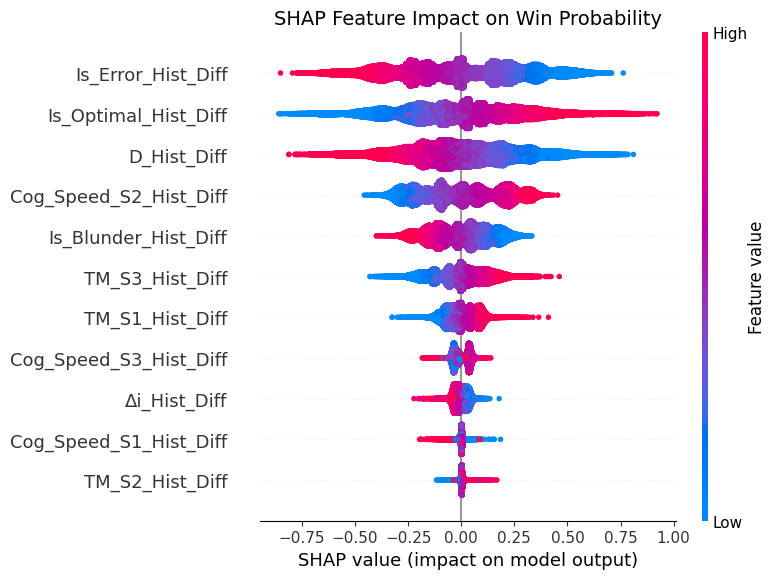

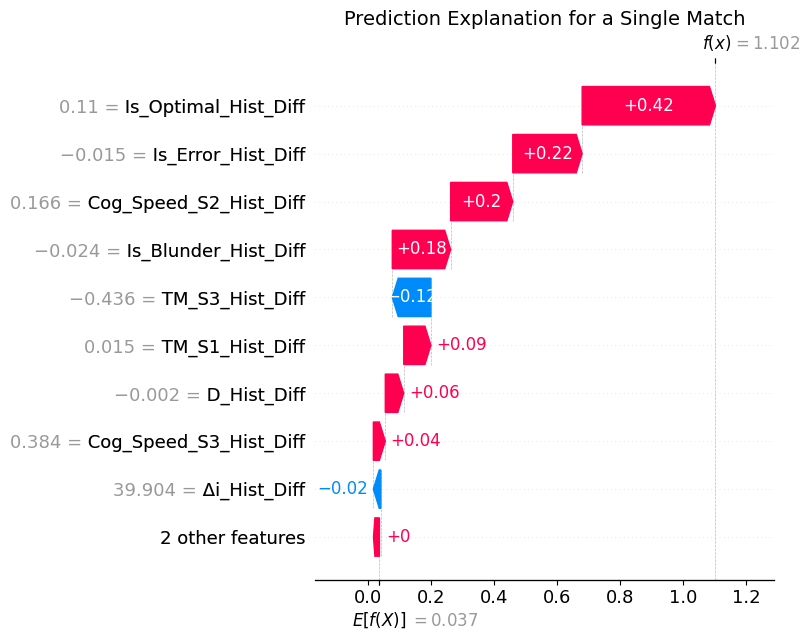

警告：特征库中没找到 Time_Management_Score_Hist


In [7]:
plt.style.use('default') 

# SHAP Explainer
explainer = shap.Explainer(clf)
shap_values_obj = explainer(X_test)

# 如果你的 lightGBM 版本导致 SHAP 输出具有第三个维度(二分类的两个类)，提取正类(Index 1)
if len(shap_values_obj.shape) == 3:
    shap_values_obj = shap_values_obj[:, :, 1]

# Figure 1: 蜂群图
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_obj, max_display=15, show=False)
plt.title("SHAP Feature Impact on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()

# Figure 2: 单独一局游戏样本
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_obj[0], max_display=10, show=False)
plt.title("Prediction Explanation for a Single Match", fontsize=14)
plt.tight_layout()
plt.show()

# Figure 3: 某个特征的趋势图
try:
    # 定义想查看的特征名称
    target_feature = "Time_Management_Score_Hist"
    color_feature = "ELO"
    
    # 手动通过列名查找对应的数字索引
    feature_names_list = list(X_test.columns)
    if target_feature in feature_names_list:
        idx_target = feature_names_list.index(target_feature)
        
        idx_color = None
        if color_feature in feature_names_list:
            idx_color = feature_names_list.index(color_feature)
            color_setting = shap_values_obj[:, idx_color]
        else:
            color_setting = shap_values_obj # SHAP 自动选择最相关的特征

        plt.figure(figsize=(8, 5))
        shap.plots.scatter(
            shap_values_obj[:, idx_target], 
            color=color_setting, 
            show=False
        )
        plt.title(f"Dependence Plot: {target_feature}", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"警告：特征库中没找到 {target_feature}")

except Exception as e:
    print(f"图 3 绘制失败，错误原因: {e}")

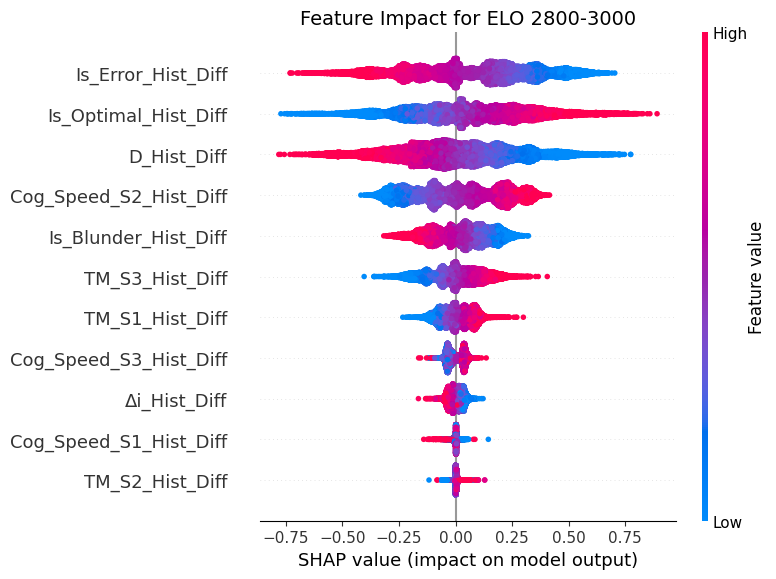

In [8]:
target_group = '2800-3000' # 或者你想看的任何组

# 找到该组在测试集中的布尔索引
group_mask = (test_df['ELO_Group'] == target_group).values

# 对 SHAP 对象进行切片
shap_values_group = shap_values_obj[group_mask]

# 绘图
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_group, max_display=15, show=False)
plt.title(f"Feature Impact for ELO {target_group}", fontsize=14)
plt.tight_layout()
plt.show()

## LSTM

In [9]:
game_features=pd.read_parquet('game_features.parquet')

In [10]:
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,TM_S1,TM_S2,TM_S3,...,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_S1_Diff,Cog_Speed_S2_Diff,Cog_Speed_S3_Diff,TM_S1_Diff,TM_S2_Diff,TM_S3_Diff,Date
0,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,-0.0,0.01,0.22,...,-0.153846,-36.307693,-0.113450,-0.227500,0.0720,-0.422500,-0.0,-0.01,-0.02,2025-04-01
1,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.0,0.02,0.24,...,0.153846,36.307693,0.113450,0.227500,-0.0720,0.422500,0.0,0.01,0.02,2025-04-01
2,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.0,0.01,-0.06,...,0.230769,768.620911,-0.061178,0.038333,-0.1425,NaN,0.0,-0.01,-0.20,2025-04-01
3,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,-0.0,0.02,0.14,...,-0.230769,-768.620911,0.061178,-0.038333,0.1425,NaN,-0.0,0.01,0.20,2025-04-01
4,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,-0.0,0.04,0.41,...,0.055263,32.728951,-0.071206,-0.156000,-0.1675,0.018333,-0.0,0.01,0.11,2025-04-01


In [11]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'TM_S1', 'TM_S2', 'TM_S3', 'ELO', 'Target', 'Cog_Speed_S1',
       'Cog_Speed_S2', 'Cog_Speed_S3', 'ELO_Diff', 'Is_Optimal_Diff',
       'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff',
       'Cog_Speed_S1_Diff', 'Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff',
       'TM_S1_Diff', 'TM_S2_Diff', 'TM_S3_Diff', 'Date'],
      dtype='object')

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

=== 特征列 Inf / -Inf 占比统计 (%) ===
Cog_Speed_S1    1.364880
Cog_Speed_S2    0.145730
Cog_Speed_S3    0.142802
dtype: float64


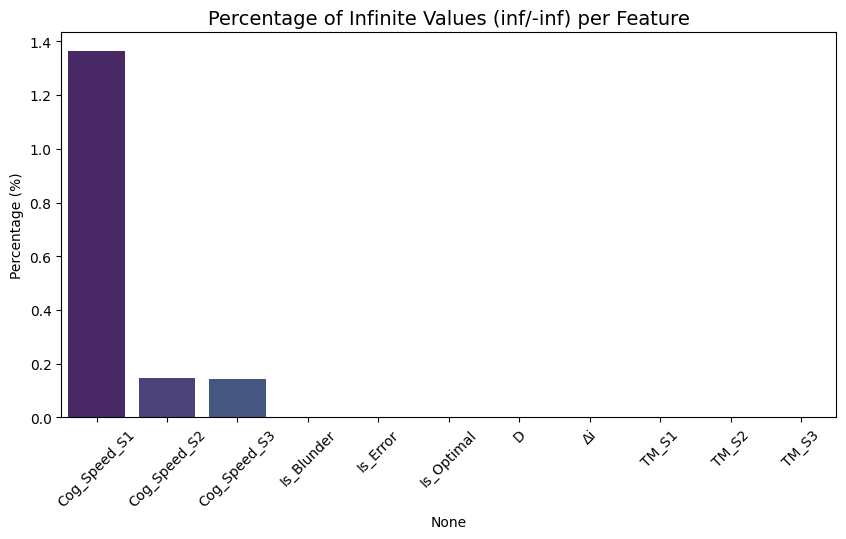

In [13]:
# 定义待检测列
check_cols = [
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 
    'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3', 
    'TM_S1', 'TM_S2', 'TM_S3'
]

# 1. 计算每一列 inf 和 -inf 的总数
inf_counts = np.isinf(game_features[check_cols]).sum()
# 2. 转化为百分比
inf_ratio = (inf_counts / len(game_features)) * 100
inf_ratio = inf_ratio.sort_values(ascending=False)

print("=== 特征列 Inf / -Inf 占比统计 (%) ===")
print(inf_ratio[inf_ratio > 0]) # 只显示有 inf 的列

if inf_ratio.max() > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=inf_ratio.index, y=inf_ratio.values, palette='viridis')
    plt.title('Percentage of Infinite Values (inf/-inf) per Feature', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\n所有特征列中均未发现 inf 或 -inf 值。")

In [14]:
def fix_cog_speed_inf(df, cols=['Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3']):
    df_fix = df.copy()
    
    for col in cols:
        # 1. 先把 inf 换成 NaN，方便后续计算
        df_fix[col] = df_fix[col].replace([np.inf, -np.inf], np.nan)
        
        # 2. 计算一个“合理的极大值”（比如 99% 分位数）
        # 既然是 inf，说明他很快，我们用该特征最快的那批数据来代替它，比中位数更贴合物理意义
        upper_limit = df_fix[col].quantile(1.00)
        
        # 3. 把 NaN (原 inf) 暂时填补为这个极大值
        df_fix[col] = df_fix[col].fillna(upper_limit)
        
        # 4. 如果还有其他原因导致的 NaN (真正的缺失值)，再用选手个人中位数填充
        player_median = df_fix.groupby('Player')[col].transform('median')
        df_fix[col] = df_fix[col].fillna(player_median)
        
    # 5. 最后全局兜底，确保没有任何 NaN 残留
    df_fix[cols] = df_fix[cols].fillna(0)
    
    return df_fix
game_features = fix_cog_speed_inf(game_features, cols=['Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3'])

In [15]:
WINDOW_SIZE = 20 
FEATURE_COLS = [
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 
    'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3', 
    'TM_S1', 'TM_S2', 'TM_S3'
]

def prepare_lstm_data_robust(df, window_size=20):
    # 1. 强力清洗数据
    df_clean = df.copy()
    
    # 将 inf 替换为 NaN，然后统一填充（用 0 或中位数）
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
    
    # 检查是否有全为空的列，如果有，填充为 0
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].fillna(0)
    
    # 确保数据类型为 float32 (对深度学习更友好)
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].astype(np.float32)

    # 2. 归一化
    scaler = StandardScaler()
    df_clean[FEATURE_COLS] = scaler.fit_transform(df_clean[FEATURE_COLS])
    
    # 3. 优化提取逻辑：先按选手分组存入字典，极大提升速度
    print("Pre-processing player sequences...")
    player_groups = {p: g[FEATURE_COLS].values for p, g in df_clean.groupby('Player')}
    # 同时记录每个选手的对局 index 映射
    player_indices = {p: g.index.tolist() for p, g in df_clean.groupby('Player')}
    
    X_a, X_b, X_static, Y = [], [], [], []
    
    # 4. 按 uid 处理对局
    # 我们以 uid 为单位，每局只需要处理一次
    matches = df_clean.groupby('uid')
    
    for uid, group in tqdm(matches, desc="Creating Samples"):
        if len(group) < 2:
            continue
            
        # 提取对局双方
        p1 = group.iloc[0]
        p2 = group.iloc[1]
        
        name1, name2 = p1['Player'], p2['Player']
        
        # 找到当前这局在选手个人历史中的位置
        idx_in_p1_hist = player_indices[name1].index(p1.name)
        idx_in_p2_hist = player_indices[name2].index(p2.name)
        
        # 判断历史是否足够
        if idx_in_p1_hist < window_size or idx_in_p2_hist < window_size:
            continue
            
        # 提取历史序列
        seq_a = player_groups[name1][idx_in_p1_hist - window_size : idx_in_p1_hist]
        seq_b = player_groups[name2][idx_in_p2_hist - window_size : idx_in_p2_hist]
        
        X_a.append(seq_a)
        X_b.append(seq_b)
        X_static.append([p1['ELO_Diff']])
        
        # 标签映射: -1->0, 0->1, 1->2
        Y.append(int(p1['Target']) + 1)
        
    return np.array(X_a), np.array(X_b), np.array(X_static, dtype=np.float32), np.array(Y)

# 使用示例
X_a, X_b, X_s, y = prepare_lstm_data_robust(game_features, window_size=WINDOW_SIZE)

Pre-processing player sequences...


Creating Samples: 100%|██████████| 1007341/1007341 [04:16<00:00, 3927.88it/s]


In [16]:
class ChessLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super(ChessLSTM, self).__init__()
        
        # 共享的 LSTM 层，用来提取两名选手的竞技状态
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        
        # 全连接层：[选手A状态 + 选手B状态 + ELO差]
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 3) # 输出 胜、平、负 三类
        )
        
    def forward(self, seq_a, seq_b, stat):
        # 提取 A 的特征
        _, (h_a, _) = self.lstm(seq_a)
        state_a = h_a[-1] # 取最后一层隐藏状态
        
        # 提取 B 的特征
        _, (h_b, _) = self.lstm(seq_b)
        state_b = h_b[-1]
        
        # 拼接
        combined = torch.cat((state_a, state_b, stat), dim=1)
        out = self.fc(combined)
        return out

# 初始化模型
model = ChessLSTM(input_dim=len(FEATURE_COLS), hidden_dim=32)

In [17]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. 转换成 Tensor
# 注意：y 需要是 Long 类型（整数），因为它是分类任务
tensor_x_a = torch.tensor(X_a, dtype=torch.float32)
tensor_x_b = torch.tensor(X_b, dtype=torch.float32)
tensor_x_s = torch.tensor(X_s, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.long)

# 2. 划分训练集和测试集 (建议按 8:2 划分)
# 在实际比赛预测中，建议直接取最后 20% 的时间段作为测试集，这里简单演示用随机划分
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# 3. 创建 Dataset 和 DataLoader
train_dataset = TensorDataset(tensor_x_a[train_idx], tensor_x_b[train_idx], tensor_x_s[train_idx], tensor_y[train_idx])
test_dataset = TensorDataset(tensor_x_a[test_idx], tensor_x_b[test_idx], tensor_x_s[test_idx], tensor_y[test_idx])

# 将 Data Loader 的 num_workers 设置为 0 (在 Windows 下更稳)，增加 batch_size
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


In [18]:
import torch.optim as optim

# 检查是否有 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 损失函数：交叉熵（适合 3 分类：胜、平、负）
criterion = nn.CrossEntropyLoss()

# 优化器：Adam 是目前的通用最佳选择
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [19]:
import torch

# --- 配置早停和保存参数 ---
epochs = 50
patience_limit = 5  # 如果连续 5 次评估（即 10 轮）准确率没提升，就停止
patience_counter = 0
best_acc = 0.0
save_path = 'best_chess_lstm.pth'

print("开始训练...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for sa, sb, stat, labels in train_loader:
        sa, sb, stat, labels = sa.to(device), sb.to(device), stat.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(sa, sb, stat)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # 每 2 轮打印一次表现，并检查是否需要早停
    if (epoch + 1) % 2 == 0:
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for sa, sb, stat, labels in test_loader:
                sa, sb, stat, labels = sa.to(device), sb.to(device), stat.to(device), labels.to(device)
                outputs = model(sa, sb, stat)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        current_acc = 100 * correct / total
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Test Acc: {current_acc:.2f}%")

        # --- 核心新增：早停与保存逻辑 ---
        if current_acc > best_acc:
            best_acc = current_acc
            patience_counter = 0  # 重置计数器
            # 保存当前最强模型参数
            torch.save(model.state_dict(), save_path)
            print(f"  --> 发现更好的模型，已保存！(Best Acc: {best_acc:.2f}%)")
        else:
            patience_counter += 1
            print(f"  --> 准确率未提升，早停计数器: {patience_counter}/{patience_limit}")

        if patience_counter >= patience_limit:
            print(f"\n[终点] 连续 {patience_limit} 次评估准确率无增长，触发早停。")
            break

# --- 训练结束后，加载表现最好的模型参数 ---
print(f"\n训练完成！正在加载最佳模型权重 (Acc: {best_acc:.2f}%)...")
model.load_state_dict(torch.load(save_path))
model.eval()
print("最佳模型已就绪，可以开始 SHAP 分析。")

开始训练...
Epoch [2/50], Loss: 0.7743, Test Acc: 67.66%
  --> 发现更好的模型，已保存！(Best Acc: 67.66%)
Epoch [4/50], Loss: 0.7740, Test Acc: 67.90%
  --> 发现更好的模型，已保存！(Best Acc: 67.90%)
Epoch [6/50], Loss: 0.7734, Test Acc: 68.19%
  --> 发现更好的模型，已保存！(Best Acc: 68.19%)
Epoch [8/50], Loss: 0.7733, Test Acc: 67.66%
  --> 准确率未提升，早停计数器: 1/5
Epoch [10/50], Loss: 0.7728, Test Acc: 67.46%
  --> 准确率未提升，早停计数器: 2/5
Epoch [12/50], Loss: 0.7729, Test Acc: 67.36%
  --> 准确率未提升，早停计数器: 3/5
Epoch [14/50], Loss: 0.7725, Test Acc: 67.84%
  --> 准确率未提升，早停计数器: 4/5
Epoch [16/50], Loss: 0.7723, Test Acc: 67.54%
  --> 准确率未提升，早停计数器: 5/5

[终点] 连续 5 次评估准确率无增长，触发早停。

训练完成！正在加载最佳模型权重 (Acc: 68.19%)...
最佳模型已就绪，可以开始 SHAP 分析。


In [20]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. 切换到评估模式 (非常重要！否则 Dropout 会导致解释结果乱跳)
model.eval()

# 2. 定义包装器：SHAP 需要一个单输入的函数
class ModelWrapper(torch.nn.Module):
    def __init__(self, model, fixed_seq_b, fixed_stat):
        super().__init__()
        self.model = model
        self.fixed_seq_b = fixed_seq_b
        self.fixed_stat = fixed_stat
        
    def forward(self, x):
        # x 是被解释的选手 A 序列
        return self.model(x, self.fixed_seq_b, self.fixed_stat)

# 3. 准备背景数据 (从训练集里抽 100 个样本，转到 CPU 跑 SHAP 更稳)
# 注意：如果显存够，可以留在 GPU；如果报错，请用 .cpu()
background = tensor_x_a[train_idx[:100]].to(device) 

# 4. 选取测试样本进行解释 (解释前 50 个测试对局)
n_explain = 50
test_samples_a = tensor_x_a[test_idx[:n_explain]].to(device)
fixed_seq_b = tensor_x_b[test_idx[:n_explain]].to(device)
fixed_stat = tensor_x_s[test_idx[:n_explain]].to(device)

# 创建包装实例
wrapper = ModelWrapper(model, fixed_seq_b, fixed_stat)

# 5. 计算 SHAP 值
# GradientExplainer 适合处理这种序列模型
explainer = shap.GradientExplainer(wrapper, background)
shap_values = explainer.shap_values(test_samples_a)

# --- 绘图部分 ---

# 我们看“预测胜利”(Index 2) 的特征贡献
# shap_values[2] 形状为 (50, 20, 11) -> (样本, 时间, 特征)
shap_win = shap_values[2]

# 降维处理：计算 20 场历史的平均贡献度，得到 (50, 11)
shap_2d = shap_win.mean(axis=1) 
# 对应的特征数值也要取平均，用于绘图显示颜色
samples_2d = test_samples_a.cpu().numpy().mean(axis=1)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_2d, samples_2d, feature_names=FEATURE_COLS, show=False)
plt.title("Overall Feature Importance (Win Prediction)", fontsize=14)
plt.show()

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 100 but got size 50 for tensor number 1 in the list.

In [ ]:
# 提取时间步的重要性：对 11 个特征取绝对值平均
# (50, 20, 11) -> (50, 20)
temporal_imp = np.abs(shap_win).mean(axis=2) 
# 对 50 个样本取平均，得到 1-20 步的趋势
time_trend = temporal_imp.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), time_trend, marker='o', linewidth=2, color='#2c3e50')
plt.xticks(range(1, 21))
plt.xlabel("Matches History (1=Oldest, 20=Latest)")
plt.ylabel("Importance Weight")
plt.title("Does recent performance matter more?")
plt.grid(alpha=0.3)
plt.show()